# Sentiment analysis: from sparse features to BERT

Companion to [Sentiment Analysis from Word2Vec to BERT: Comparing Approaches](https://nanx.cc/2020/04/25/sentiment-analysis-from-word2vec-to-bert.html). Added September 2026; this is a new implementation, not recovered output from a 2020 experiment.

We build four classifiers on the same IMDb review IDs: **TF-IDF + logistic regression**, **mean Word2Vec + logistic regression**, **BiLSTM**, and **fine-tuned BERT**. Each section includes training, validation, and prediction code. The final section optionally evaluates the held-out test split and exports the evidence.

**Recorded Colab run — 22 September 2026 (Singapore):** the saved code, execution counts, outputs, plot, and warnings below are preserved from the completed quick-mode run. Only explanatory Markdown has been updated for publication; no cells were rerun. This run used 2,000 training reviews and 500 validation reviews, seed 42, and one epoch for each neural model. `RUN_TEST = False`: the held-out test set was not evaluated.

## Read the saved walkthrough

[View on nbviewer](https://nbviewer.org/github/xia0nan/xia0nan.github.io/blob/master/notebooks/sentiment-analysis-from-word2vec-to-bert.ipynb) to read the code, saved tables, plot, and training output without running anything. Open the [shared Colab notebook](https://colab.research.google.com/drive/1tFnKYPX37N7kmoqgKaEtL0qfo1E1DK33?usp=sharing) to view the original run or save your own copy. The nbviewer link displays this repository snapshot once it is published to `master`.

## Run your own copy (optional)

Open the [shared Colab notebook](https://colab.research.google.com/drive/1tFnKYPX37N7kmoqgKaEtL0qfo1E1DK33?usp=sharing) and choose **File → Save a copy in Drive** before experimenting. You can also upload this `.ipynb` directly to Colab. Select **Runtime → Change runtime type → GPU** for BERT. The recorded runtime reports **Python 3.13.15, Transformers 5.16.1, and PyTorch 2.11.0+cu128**, with CUDA enabled and a T4 GPU in the notebook metadata. The setup cell was changed during the Colab session to install unpinned packages; a later run may therefore resolve different versions. It removes the unused torchvision/torchaudio packages before installing the text-model dependencies. GPU availability and Colab's preinstalled environment can vary. After setup, **restart the session**, then run from the configuration cell onward. Do not rerun setup after the restart.

Run cells in order. Downloads require internet access: the labeled IMDb data and, if enabled, the BERT checkpoint. Allow several GB of disk for caches and checkpoints. CPU readers can set `RUN_BERT = False` and complete the other approaches; BERT remains fully implemented below.

`MODE = "quick"` uses 2,000 training and 500 validation reviews and one neural epoch. `"full"` uses 20,000 training / 5,000 validation reviews and three neural epochs. Neither is an exhaustive hyperparameter search. Keep `RUN_TEST = False` while developing; enable it only after fixing your choices. Run artifacts are saved in a new timestamped directory, which you should download before a hosted session expires.


## Recorded validation results

| Model | Accuracy | Binary F1 (positive = 1) |
| --- | ---: | ---: |
| TF-IDF + logistic regression | 85.4% | 0.8543 |
| Mean Word2Vec + logistic regression | 78.2% | 0.7883 |
| BiLSTM | 54.8% | 0.5150 |
| BERT (provisional; see warning below) | 88.2% | 0.8808 |

These are the saved final validation outputs on 500 reviews (250 per class), using threshold 0.5. They are not held-out test scores. Validation F1 was also used to select settings, so these numbers are selection results, not an independent estimate after tuning. TF-IDF selected `C=10`; Word2Vec selected `C=0.1`. Both neural models ran for one epoch. Quick mode and one seed do not establish a general ranking.

**BERT checkpoint warning:** the saved training output reports missing LayerNorm `weight`/`bias` keys and unexpected `gamma`/`beta` keys while loading a checkpoint. This is separate from the expected initialization of the sentiment head. The notebook still records a final prediction result, but correct restoration of all fine-tuned parameters has not been verified. The BERT score is retained as observed output and remains provisional; the warning has not been repaired or hidden.

The notebook preserves displayed outputs, including the training-length histogram and confusion matrices. The run's separate `manifest.json`, prediction CSVs, split-ID files, and model checkpoints were written in the Colab session but are **not bundled here**. In particular, the resolved dataset and model revision SHAs are not printed in this notebook. Reading the saved results requires no downloads or rerun.



In [2]:
%pip uninstall -y torchvision torchaudio
%pip install numpy scipy pandas scikit-learn gensim torch transformers datasets accelerate matplotlib joblib huggingface-hub
print("Setup complete. Restart the session, then continue at the configuration cell.")

Setup complete. Restart the session, then continue at the configuration cell.


In [13]:
import sys
import transformers
import torch

print("Python:", sys.version)
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Transformers: 5.16.1
PyTorch: 2.11.0+cu128
CUDA: True


In [3]:
import hashlib
import html
import importlib.metadata
import json
import platform
import random
import re
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from datasets import load_dataset
from gensim.models import Word2Vec
from huggingface_hub import HfApi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    DataCollatorWithPadding, Trainer, TrainingArguments, set_seed,
)

MODE = "quick"  # "quick" or "full"
RUN_BERT = True
RUN_TEST = False  # Enable only after model/settings selection is finished.
SEED = 42
DATASET_ID = "stanfordnlp/imdb"
BERT_ID = "google-bert/bert-base-uncased"
# Set these to a saved manifest's SHAs to replay that exact dataset/checkpoint.
DATASET_REVISION = None
BERT_REVISION = None
assert MODE in {"quick", "full"}
EPOCHS = 1 if MODE == "quick" else 3
MAX_LENGTH = 256  # First 256 words for BiLSTM; 256 subwords incl. specials for BERT.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

OUT = Path("sentiment-runs") / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT.mkdir(parents=True, exist_ok=False)
packages = ["numpy", "scipy", "pandas", "scikit-learn", "gensim", "torch",
            "transformers", "datasets", "accelerate", "matplotlib", "joblib", "huggingface-hub"]
manifest = {
    "mode": MODE, "seed": SEED, "epochs": EPOCHS, "max_length": MAX_LENGTH,
    "run_bert": RUN_BERT, "python": platform.python_version(),
    "platform": platform.platform(), "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else None,
    "versions": {name: importlib.metadata.version(name) for name in packages},
    "positive_label": 1, "f1_average": "binary", "threshold": 0.5,
}

def write_manifest():
    (OUT / "manifest.json").write_text(json.dumps(manifest, indent=2))

write_manifest()
print("Device:", DEVICE, "Artifacts:", OUT)


Device: cuda Artifacts: sentiment-runs/20260921T222537108629Z


## 1. Fix the splits before learning any vocabulary

The [Stanford dataset](https://ai.stanford.edu/~amaas/data/sentiment/) supplies 25,000 labeled training and 25,000 labeled test reviews. We leave the 50,000 unlabeled examples unused. Label `0` means negative, `1` positive.

First split the official training set 80/20 with stratification. Quick mode then draws stratified subsets from those partitions, rather than taking the first rows (which can be sorted by label). The test split is loaded only in the final, opt-in evaluation. Row IDs are namespaced by the official split and refer to the resolved dataset revision. We also save text hashes so a future run can check the data identity.


In [4]:
api = HfApi()
dataset_revision = DATASET_REVISION or api.dataset_info(DATASET_ID).sha
manifest["dataset"] = {"id": DATASET_ID, "revision": dataset_revision}
official_train = load_dataset(DATASET_ID, revision=dataset_revision, split="train")
official_train = official_train.add_column("review_id", [f"train:{i}" for i in range(len(official_train))])
train_ids, val_ids = train_test_split(
    np.arange(len(official_train)), test_size=0.2,
    stratify=official_train["label"], random_state=SEED,
)

def subset(ds, size):
    if size is None or size >= len(ds):
        return ds
    selected, _ = train_test_split(
        np.arange(len(ds)), train_size=size, stratify=ds["label"], random_state=SEED,
    )
    return ds.select(selected.tolist())

train = subset(official_train.select(train_ids.tolist()), 2000 if MODE == "quick" else None)
val = subset(official_train.select(val_ids.tolist()), 500 if MODE == "quick" else None)
assert set(train["review_id"]).isdisjoint(val["review_id"])

def save_split(ds, split_name):
    rows = pd.DataFrame({
        "review_id": ds["review_id"], "label": ds["label"],
        "text_sha256": [hashlib.sha256(t.encode()).hexdigest() for t in ds["text"]],
    })
    rows.to_csv(OUT / f"{split_name}-ids.csv", index=False)

save_split(train, "train")
save_split(val, "validation")
manifest["split_sizes"] = {"train": len(train), "validation": len(val)}
write_manifest()
display(pd.DataFrame({"train": Counter(train["label"]), "validation": Counter(val["label"])}))


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,train,validation
0,1000,250
1,1000,250


## 2. Inspect training text and preserve negation

Strip HTML markup and decode entities, but keep the words. Our word tokenizer lowercases and preserves contractions such as `isn't`; it removes punctuation and numbers. This is an explicit baseline choice, not a universal cleaning rule. We do not remove stopwords. BERT receives cleaned review text through its own subword tokenizer, without this word tokenizer or lowercasing step.

The histogram and quantiles below are computed from the training subset. We keep the **start** of long reviews for both neural models. Words and BERT subwords are different units, so the same numeric length limit does not give identical text coverage.


Word-count quantiles: [  15.    175.    455.1   607.05 1099.  ]
Fraction truncated by BiLSTM: 0.286


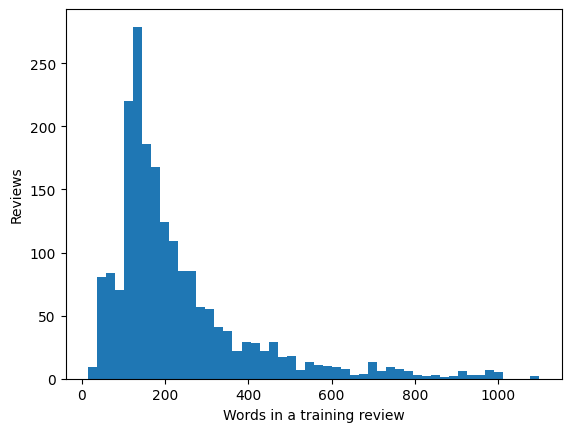

In [5]:
def clean_html(text):
    return re.sub(r"\s+", " ", html.unescape(re.sub(r"<[^>]+>", " ", text))).strip()

def word_tokens(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", clean_html(text).lower().replace("’", "'"))

assert word_tokens("<b>Not</b> good; isn't great!") == ["not", "good", "isn't", "great"]
train_tokens = [word_tokens(t) for t in train["text"]]
val_tokens = [word_tokens(t) for t in val["text"]]
lengths = np.array([len(tokens) for tokens in train_tokens])
print("Word-count quantiles:", np.quantile(lengths, [0, .5, .9, .95, 1]))
print("Fraction truncated by BiLSTM:", float(np.mean(lengths > MAX_LENGTH)))
plt.hist(lengths, bins=50)
plt.xlabel("Words in a training review")
plt.ylabel("Reviews")
plt.show()


## 3. Use one evaluation contract

Every model returns a probability for label `1`. We use a fixed threshold of `0.5`, accuracy, and binary F1 with positive label `1`. Confusion matrices use rows = true label, columns = predicted label, ordered `[negative, positive]`. Predictions are exported with review IDs; model selection uses validation F1 only. These probabilities are not calibrated confidence estimates.


In [6]:
scores = []
predictors = {}

def metrics(labels, probabilities):
    predictions = (np.asarray(probabilities) >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, pos_label=1, average="binary", zero_division=0),
    }

def record(name, ds, probabilities, split_name):
    probabilities = np.asarray(probabilities)
    assert probabilities.shape == (len(ds),)
    assert np.isfinite(probabilities).all() and ((probabilities >= 0) & (probabilities <= 1)).all()
    predictions = (probabilities >= 0.5).astype(int)
    row = {"model": name, "split": split_name, "n": len(ds), **metrics(ds["label"], probabilities)}
    scores.append(row)
    pd.DataFrame({"review_id": ds["review_id"], "label": ds["label"],
                  "probability_positive": probabilities, "prediction": predictions}).to_csv(
        OUT / f"{name}-{split_name}-predictions.csv", index=False)
    matrix = confusion_matrix(ds["label"], predictions, labels=[0, 1])
    (OUT / f"{name}-{split_name}-confusion.json").write_text(json.dumps(matrix.tolist()))
    print(row, "\nConfusion matrix:\n", matrix)


## 4. TF-IDF + logistic regression

Unigrams and bigrams retain evidence such as `not good`. Fit document frequencies and the vocabulary on training text only. We select logistic regression's regularization strength `C` from three candidates on validation F1, with the first candidate winning ties. Larger `C` means less regularization. The vectorizer is shared across candidates because its settings are fixed.


In [7]:
vectorizer = TfidfVectorizer(
    tokenizer=word_tokens, token_pattern=None, lowercase=False,
    ngram_range=(1, 2), min_df=2, max_features=50000, sublinear_tf=True,
)
x_train = vectorizer.fit_transform(train["text"])
x_val = vectorizer.transform(val["text"])

def choose_logistic(x_fit, y_fit, x_valid, y_valid, scale=False):
    best_model, best_f1, best_c = None, -1, None
    for c in (0.1, 1.0, 10.0):
        classifier = LogisticRegression(C=c, max_iter=1000, random_state=SEED)
        candidate = make_pipeline(StandardScaler(), classifier) if scale else classifier
        candidate.fit(x_fit, y_fit)
        score = metrics(y_valid, candidate.predict_proba(x_valid)[:, 1])["f1"]
        print(f"C={c}: validation F1={score:.4f}")
        if score > best_f1:
            best_model, best_f1, best_c = candidate, score, c
    return best_model, best_c

tfidf_clf, tfidf_c = choose_logistic(x_train, train["label"], x_val, val["label"])
predictors["tfidf"] = lambda texts: tfidf_clf.predict_proba(vectorizer.transform(texts))[:, 1]
record("tfidf", val, predictors["tfidf"](val["text"]), "validation")
joblib.dump({"vectorizer": vectorizer, "classifier": tfidf_clf}, OUT / "tfidf.joblib")
manifest["tfidf"] = {"C": tfidf_c, "ngram_range": [1, 2], "min_df": 2,
                     "max_features": 50000, "sublinear_tf": True}


C=0.1: validation F1=0.8182
C=1.0: validation F1=0.8423
C=10.0: validation F1=0.8543
{'model': 'tfidf', 'split': 'validation', 'n': 500, 'accuracy': 0.854, 'f1': 0.8542914171656687} 
Confusion matrix:
 [[213  37]
 [ 36 214]]


## 5. Mean Word2Vec + logistic regression

Train 100-dimensional skip-gram vectors on the training reviews only, then average known token vectors within each review. This turns a variable-length list into one fixed-size vector, without the invalid TF-IDF/token-dimension multiplication in the old article. Repeated words contribute repeatedly; word order is lost. Reviews with no known words receive a zero vector, and we count them explicitly.

Standardize the dense features inside each classifier pipeline, fitting that scaler on training vectors only. Word2Vec uses one worker and a stable hash function to reduce run-to-run variation. Exact numerical reproduction across hardware and library versions is still not guaranteed.


In [8]:
def stable_hash(word):
    return int.from_bytes(hashlib.sha256(word.encode()).digest()[:4], "little")

w2v = Word2Vec(
    sentences=train_tokens, vector_size=100, window=5, min_count=2,
    sg=1, negative=5, epochs=5, seed=SEED, workers=1, hashfxn=stable_hash,
)

def mean_vectors(token_lists):
    vectors = np.zeros((len(token_lists), w2v.vector_size), dtype=np.float32)
    empty = 0
    for i, tokens in enumerate(token_lists):
        known = [w2v.wv[token] for token in tokens if token in w2v.wv]
        if known:
            vectors[i] = np.mean(known, axis=0)
        else:
            empty += 1
    return vectors, empty

w_train, train_empty = mean_vectors(train_tokens)
w_val, val_empty = mean_vectors(val_tokens)
print("No-known-token reviews:", {"train": train_empty, "validation": val_empty})
w2v_clf, w2v_c = choose_logistic(w_train, train["label"], w_val, val["label"], scale=True)

def predict_w2v(texts):
    vectors, empty = mean_vectors([word_tokens(t) for t in texts])
    print(f"Word2Vec zero-vector reviews: {empty}/{len(texts)}")
    return w2v_clf.predict_proba(vectors)[:, 1]

predictors["word2vec"] = predict_w2v
record("word2vec", val, predict_w2v(val["text"]), "validation")
w2v.wv.save(str(OUT / "word2vec.kv"))
joblib.dump(w2v_clf, OUT / "word2vec-classifier.joblib")
manifest["word2vec"] = {"C": w2v_c, "vector_size": 100, "window": 5,
                        "min_count": 2, "sg": 1, "negative": 5, "epochs": 5, "workers": 1}


No-known-token reviews: {'train': 0, 'validation': 0}
C=0.1: validation F1=0.7883
C=1.0: validation F1=0.7823
C=10.0: validation F1=0.7814
Word2Vec zero-vector reviews: 0/500
{'model': 'word2vec', 'split': 'validation', 'n': 500, 'accuracy': 0.782, 'f1': 0.7883495145631068} 
Confusion matrix:
 [[188  62]
 [ 47 203]]


## 6. BiLSTM with explicit lengths

Fit a word vocabulary on training reviews; reserve `0` for padding and `1` for unknown words. The embedding starts randomly and is trained with the classifier (it is not initialized from Word2Vec). We pack sequences with their true lengths so padding cannot become evidence, especially in the backward LSTM. An empty token list becomes one unknown token.

Concatenate the final forward and backward hidden states: 64 units in each direction produce a 128-dimensional review representation. Train with cross-entropy, clip gradient norm to 1, and restore the checkpoint with the highest validation F1. This notebook shares PyTorch with BERT, so no second deep-learning framework is required.


In [9]:
counts = Counter(token for tokens in train_tokens for token in tokens)
vocab = {word: i + 2 for i, (word, _) in enumerate(counts.most_common(19998))}

def encode_words(text):
    ids = [vocab.get(token, 1) for token in word_tokens(text)[:MAX_LENGTH]]
    return torch.tensor(ids or [1], dtype=torch.long)

def collate_reviews(rows):
    sequences, labels = zip(*rows)
    lengths = torch.tensor([len(sequence) for sequence in sequences])
    return pad_sequence(sequences, batch_first=True, padding_value=0), lengths, torch.tensor(labels)

def review_loader(texts, labels=None, shuffle=False):
    if labels is None:
        labels = [0] * len(texts)  # Dummy labels are ignored for inference.
    rows = [(encode_words(text), label) for text, label in zip(texts, labels)]
    return DataLoader(rows, batch_size=32, shuffle=shuffle, collate_fn=collate_reviews,
                      generator=torch.Generator().manual_seed(SEED))

class BiLSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 100, padding_idx=0)
        self.lstm = nn.LSTM(100, 64, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(128, 2))

    def forward(self, ids, lengths):
        packed = pack_padded_sequence(self.embedding(ids), lengths.cpu(),
                                      batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        return self.head(torch.cat([hidden[-2], hidden[-1]], dim=1))

set_seed(SEED)
LSTM_DEVICE = DEVICE
lstm = BiLSTM(len(vocab) + 2).to(LSTM_DEVICE)

@torch.no_grad()
def predict_lstm(texts):
    lstm.eval()
    probabilities = []
    for ids, lengths, _ in review_loader(texts):
        logits = lstm(ids.to(LSTM_DEVICE), lengths)
        probabilities.extend(logits.softmax(dim=1)[:, 1].cpu().numpy())
    return np.asarray(probabilities)


In [10]:
optimizer = torch.optim.AdamW(lstm.parameters(), lr=1e-3, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
best_f1, best_epoch = -1, None
train_loader = review_loader(train["text"], train["label"], shuffle=True)
for epoch in range(EPOCHS):
    lstm.train()
    total_loss = 0.0
    for ids, lengths, labels in train_loader:
        optimizer.zero_grad()
        logits = lstm(ids.to(LSTM_DEVICE), lengths)
        loss = criterion(logits, labels.to(LSTM_DEVICE))
        loss.backward()
        nn.utils.clip_grad_norm_(lstm.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
    score = metrics(val["label"], predict_lstm(val["text"]))["f1"]
    print(f"Epoch {epoch + 1}: train loss={total_loss / len(train):.4f}, validation F1={score:.4f}")
    if score > best_f1:
        best_f1, best_epoch = score, epoch + 1
        torch.save(lstm.state_dict(), OUT / "bilstm.pt")

lstm.load_state_dict(torch.load(OUT / "bilstm.pt", map_location=LSTM_DEVICE, weights_only=True))
predictors["bilstm"] = predict_lstm
record("bilstm", val, predict_lstm(val["text"]), "validation")
(OUT / "bilstm-vocab.json").write_text(json.dumps(vocab))
manifest["bilstm"] = {"best_epoch": best_epoch, "embedding_dim": 100, "hidden_size": 64,
                      "dropout": 0.3, "batch_size": 32, "lr": 1e-3, "weight_decay": 0.01,
                      "max_vocab": 20000, "clip_grad_norm": 1.0}
# Keep this small model on CPU while BERT uses the GPU.
lstm.to("cpu")
LSTM_DEVICE = torch.device("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Epoch 1: train loss=0.6907, validation F1=0.5150
{'model': 'bilstm', 'split': 'validation', 'n': 500, 'accuracy': 0.548, 'f1': 0.5150214592274678} 
Confusion matrix:
 [[154  96]
 [130 120]]


## 7. Fine-tune pretrained BERT

Use [BERT base uncased](https://huggingface.co/google-bert/bert-base-uncased) and its matching tokenizer at the same resolved checkpoint revision. The sentiment head is newly initialized; fine-tuning updates both the head and the pretrained encoder. The model card describes its pretraining data and limitations. Unlike the locally trained models, BERT brings outside pretraining into this experiment; this is not a controlled comparison of architecture alone.

Dynamic padding pads to the longest sequence in each batch. Truncate at 256 subwords including special tokens. We select the best epoch using validation F1, with the test data excluded from `Trainer`. All settings below are starting points, not claimed optima. Reduce batch size if GPU memory is insufficient, and record that change. CPU training is possible but can be slow.


In [12]:
if RUN_BERT:
    set_seed(SEED)

    bert_revision = BERT_REVISION or api.model_info(BERT_ID).sha

    bert_tokenizer = AutoTokenizer.from_pretrained(
        BERT_ID,
        revision=bert_revision,
    )

    bert_model = AutoModelForSequenceClassification.from_pretrained(
        BERT_ID,
        revision=bert_revision,
        num_labels=2,
        id2label={0: "negative", 1: "positive"},
        label2id={"negative": 0, "positive": 1},
    )

    def tokenize_bert(ds):
        return ds.map(
            lambda batch: bert_tokenizer(
                [clean_html(t) for t in batch["text"]],
                truncation=True,
                max_length=MAX_LENGTH,
            ),
            batched=True,
            remove_columns=[
                name for name in ds.column_names
                if name != "label"
            ],
        )

    bert_train = tokenize_bert(train)
    bert_val = tokenize_bert(val)

    bert_args = TrainingArguments(
        output_dir=str(OUT / "bert-checkpoints"),

        num_train_epochs=EPOCHS,
        learning_rate=2e-5,
        weight_decay=0.01,

        # Transformers 5.x:
        # float < 1 is interpreted as fraction of total training steps.
        warmup_steps=0.1,

        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,

        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        seed=SEED,
        data_seed=SEED,

        report_to="none",
        optim="adamw_torch",

        use_cpu=not torch.cuda.is_available(),
        dataloader_pin_memory=torch.cuda.is_available(),
    )

    def bert_metrics(prediction):
        probabilities = (
            torch.tensor(prediction.predictions)
            .softmax(dim=1)[:, 1]
            .numpy()
        )

        return metrics(
            prediction.label_ids,
            probabilities,
        )

    trainer = Trainer(
        model=bert_model,
        args=bert_args,
        train_dataset=bert_train,
        eval_dataset=bert_val,
        processing_class=bert_tokenizer,
        data_collator=DataCollatorWithPadding(bert_tokenizer),
        compute_metrics=bert_metrics,
    )

    trainer.train()

    trainer.save_model(str(OUT / "bert-best"))
    bert_tokenizer.save_pretrained(OUT / "bert-best")

    def predict_bert(texts):
        from datasets import Dataset

        encoded = tokenize_bert(
            Dataset.from_dict({"text": list(texts)})
        )

        logits = trainer.predict(encoded).predictions

        return (
            torch.tensor(logits)
            .softmax(dim=1)[:, 1]
            .numpy()
        )

    predictors["bert"] = predict_bert

    record(
        "bert",
        val,
        predict_bert(val["text"]),
        "validation",
    )

    manifest["bert"] = {
        "id": BERT_ID,
        "revision": bert_revision,
        "best_checkpoint": trainer.state.best_model_checkpoint,
        "training_arguments": bert_args.to_dict(),
    }

else:
    print(
        "BERT skipped. Enable RUN_BERT and rerun from "
        "configuration to compare all four models."
    )

write_manifest()
display(pd.DataFrame(scores))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.300010,0.882000,0.880808


...

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

{'model': 'bert', 'split': 'validation', 'n': 500, 'accuracy': 0.882, 'f1': 0.8808080808080808} 
Confusion matrix:
 [[223  27]
 [ 32 218]]


,model,split,n,accuracy,f1
0,tfidf,validation,500,0.854,0.854291
1,word2vec,validation,500,0.782,0.788350
2,bilstm,validation,500,0.548,0.515021
3,bert,validation,500,0.882,0.880808


## 8. Freeze choices, then evaluate the held-out test set

Do not repeatedly use test scores to tune the models. Keep `RUN_TEST = False` while exploring. Once settings are fixed, set it to `True` and run this cell. Quick mode uses a stratified 1,000-review test subset; full mode uses the entire 25,000-review official test split. The code saves the precise IDs in either case.

This cell evaluates all enabled approaches with the same labels, threshold, and metrics, and does no fitting. Re-running it in the same session is blocked to discourage accidental repeated evaluation. A new session cannot prevent deliberate test reuse: the experimental protocol remains your responsibility.


In [14]:
if RUN_TEST:
    if any(row["split"] == "test" for row in scores):
        raise RuntimeError("Test already evaluated in this run. Do not tune against these scores.")
    test = load_dataset(DATASET_ID, revision=dataset_revision, split="test")
    test = test.add_column("review_id", [f"test:{i}" for i in range(len(test))])
    test = subset(test, 1000 if MODE == "quick" else None)
    save_split(test, "test")
    for name, predictor in predictors.items():
        record(name, test, predictor(test["text"]), "test")
    manifest["split_sizes"]["test"] = len(test)
    manifest["test_evaluated"] = True
else:
    print("Test untouched. Set RUN_TEST=True only after finalizing the experiment.")

pd.DataFrame(scores).to_csv(OUT / "metrics.csv", index=False)
write_manifest()
display(pd.DataFrame(scores))


Test untouched. Set RUN_TEST=True only after finalizing the experiment.


,model,split,n,accuracy,f1
0,tfidf,validation,500,0.854,0.854291
1,word2vec,validation,500,0.782,0.788350
2,bilstm,validation,500,0.548,0.515021
3,bert,validation,500,0.882,0.880808


## 9. Inspect validation errors and export the run

Look at validation mistakes while developing, rather than reading test examples and then tuning to them. Are negations missed? Does the label depend on text beyond the truncation limit? Does a review mix praise and criticism? These examples generate hypotheses; they do not by themselves explain a model's mechanism.


In [15]:
validation_predictions = pd.read_csv(OUT / "tfidf-validation-predictions.csv")
errors = validation_predictions.query("label != prediction").head(5).copy()
text_by_id = dict(zip(val["review_id"], val["text"]))
errors["review_excerpt"] = [clean_html(text_by_id[i])[:500] for i in errors["review_id"]]
display(errors)
print("Save this run directory before ending the session:", OUT.resolve())

# Optional: archive artifacts, including model weights (can be large).
# import shutil
# archive = shutil.make_archive(str(OUT), "zip", root_dir=OUT)
# In Colab: from google.colab import files; files.download(archive)


,review_id,label,probability_positive,prediction,review_excerpt
9,train:14065,1,0.430555,0,I first caught the movie on its first run on H...
25,train:16630,1,0.415580,0,Richard Widmark is a tainted character in this...
41,train:1633,0,0.561401,1,"For the knowledgeable Beatles fan, the main va..."
45,train:23143,1,0.455888,0,I could see this film is super He didn't surpr...
47,train:20006,1,0.415659,0,This film was just absolutly brilliant. It act...


Save this run directory before ending the session: /content/sentiment-runs/20260921T222537108629Z


## What this run can establish

The exported metrics describe the selected configuration on these exact splits. Quick mode is a workflow check, not a benchmark. Even full mode is one seed and a small, unequal search budget: logistic regression tries three regularization values, whereas the neural models select among epochs at a fixed learning rate. Keep that asymmetry visible in any comparison.

Before claiming one model is better, repeat training with several seeds, preserve a consistent split, report variation, and state the tuning budget. BERT's external pretraining, differing tokenization, and truncation are part of the comparison. This notebook does not measure serving latency or energy use; do not infer a speed ranking from it. For deployment, also assess calibration, domain shift, and representative serving hardware.

`manifest.json` records resolved dataset/model revisions, direct package versions, hardware, settings and selected checkpoints. CSVs hold split IDs, text hashes, predictions and metrics; JSON files hold confusion matrices. Saved model artifacts allow inference with the corresponding preprocessing functions in this notebook. Save the executed notebook too: it records your edited code and figures, which the manifest alone cannot recover. Only load pickle/joblib artifacts you trust.

## References

- [IMDb dataset and original paper](https://ai.stanford.edu/~amaas/data/sentiment/)
- [scikit-learn text feature extraction](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)
- [Gensim Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html)
- [PyTorch packed sequences](https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pack_padded_sequence.html)
- [BERT paper](https://aclanthology.org/N19-1423/) and [checkpoint model card](https://huggingface.co/google-bert/bert-base-uncased)
- [Transformers 4.51.3 Trainer API](https://huggingface.co/docs/transformers/v4.51.3/en/main_classes/trainer)
